### Importing necessary Python libraries for data manipulation and visualization

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Create dataframe

In [107]:
df = pd.read_csv("zomato-data.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


### Data cleaning

In [108]:
def clean_rate(value):
    if pd.isna(value) or str(value).strip() == '-':
        return np.nan

    value = str(value).split('/')[0]
    value = value.strip()

    try:
        return float(value)
    except ValueError:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)

df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


In [109]:
df.isna().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

### Categrories restaurant by types

In [110]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'Type of restaurant')

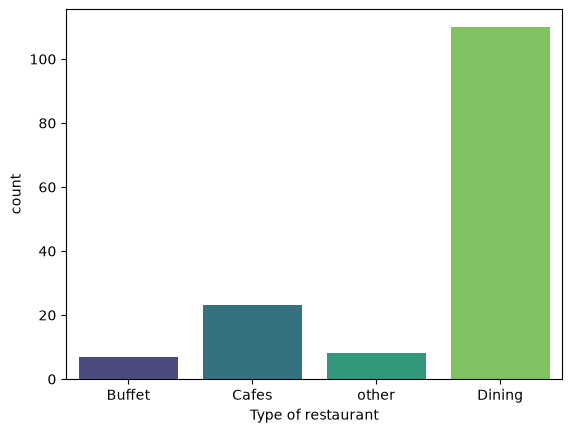

In [111]:
sns.countplot(x=df['listed_in(type)'], hue=df['listed_in(type)'], palette='viridis' )
plt.xlabel("Type of restaurant")

Text(0, 0.5, 'Votes')

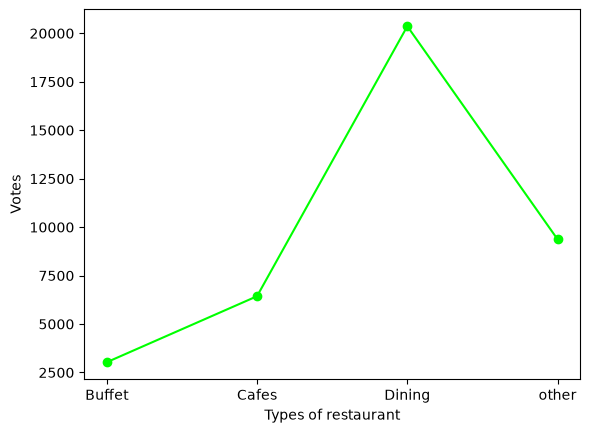

In [112]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()

result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='lime', marker='o')
plt.xlabel('Types of restaurant')
plt.ylabel('Votes')

### Identify the most voted restaurant

In [49]:
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes'] == max_votes, 'name']
print(restaurant_with_max_votes)

38    Empire Restaurant
Name: name, dtype: str


### Online Availability

<Axes: xlabel='online_order', ylabel='count'>

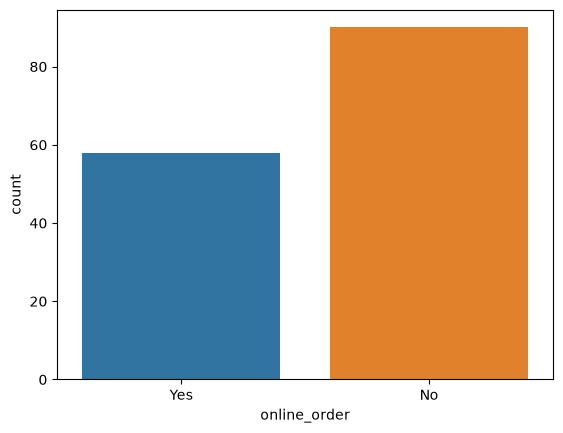

In [63]:
sns.countplot(x=df['online_order'], hue=df['online_order'])

### Rating Distribution

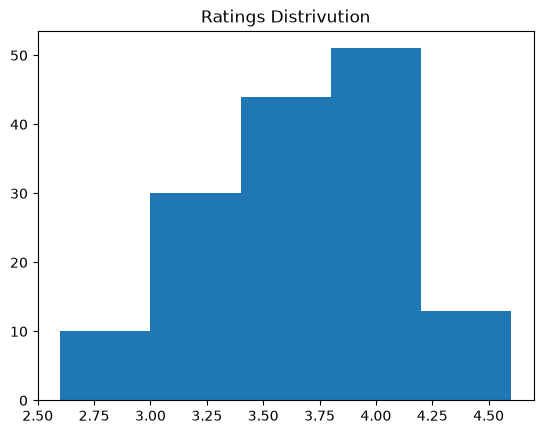

In [113]:
plt.hist(df['rate'], bins=5)
plt.title('Ratings Distrivution')
plt.show()

### Cost for Couples

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

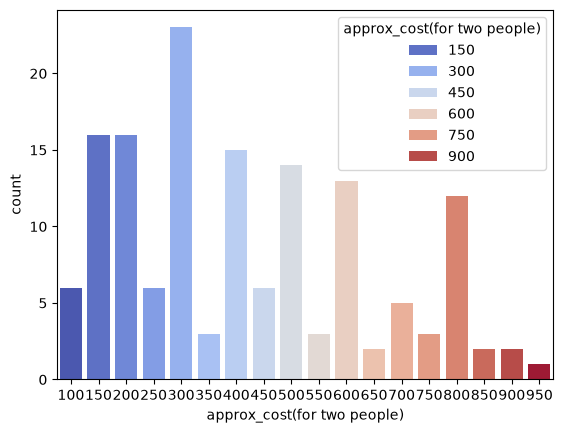

In [114]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x=couple_data, hue= df['approx_cost(for two people)'], palette='coolwarm')

### Rating Comparison - Online vs Offline Orders

<Axes: xlabel='online_order', ylabel='rate'>

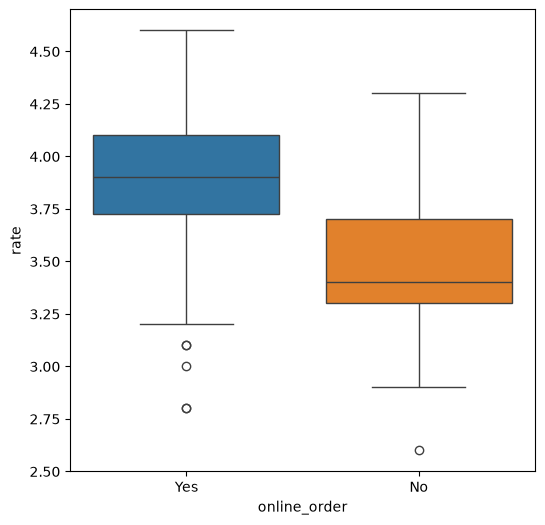

In [115]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order', y= 'rate', data=df, hue=df['online_order'])

### Order Mode Preferences by Restaurant Type

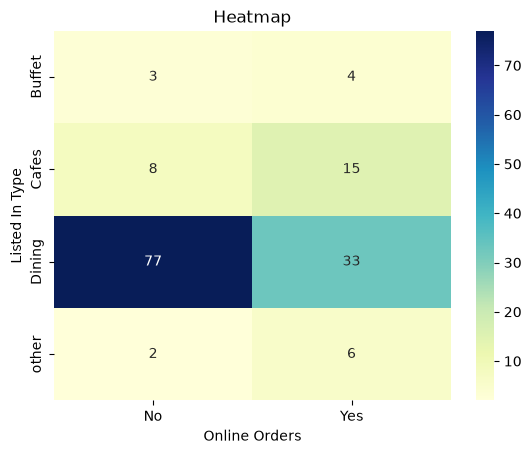

In [116]:
pivot_table= df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Orders')
plt.ylabel('Listed In Type')
plt.show()